In [3]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("BostonHousing.csv")
df.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


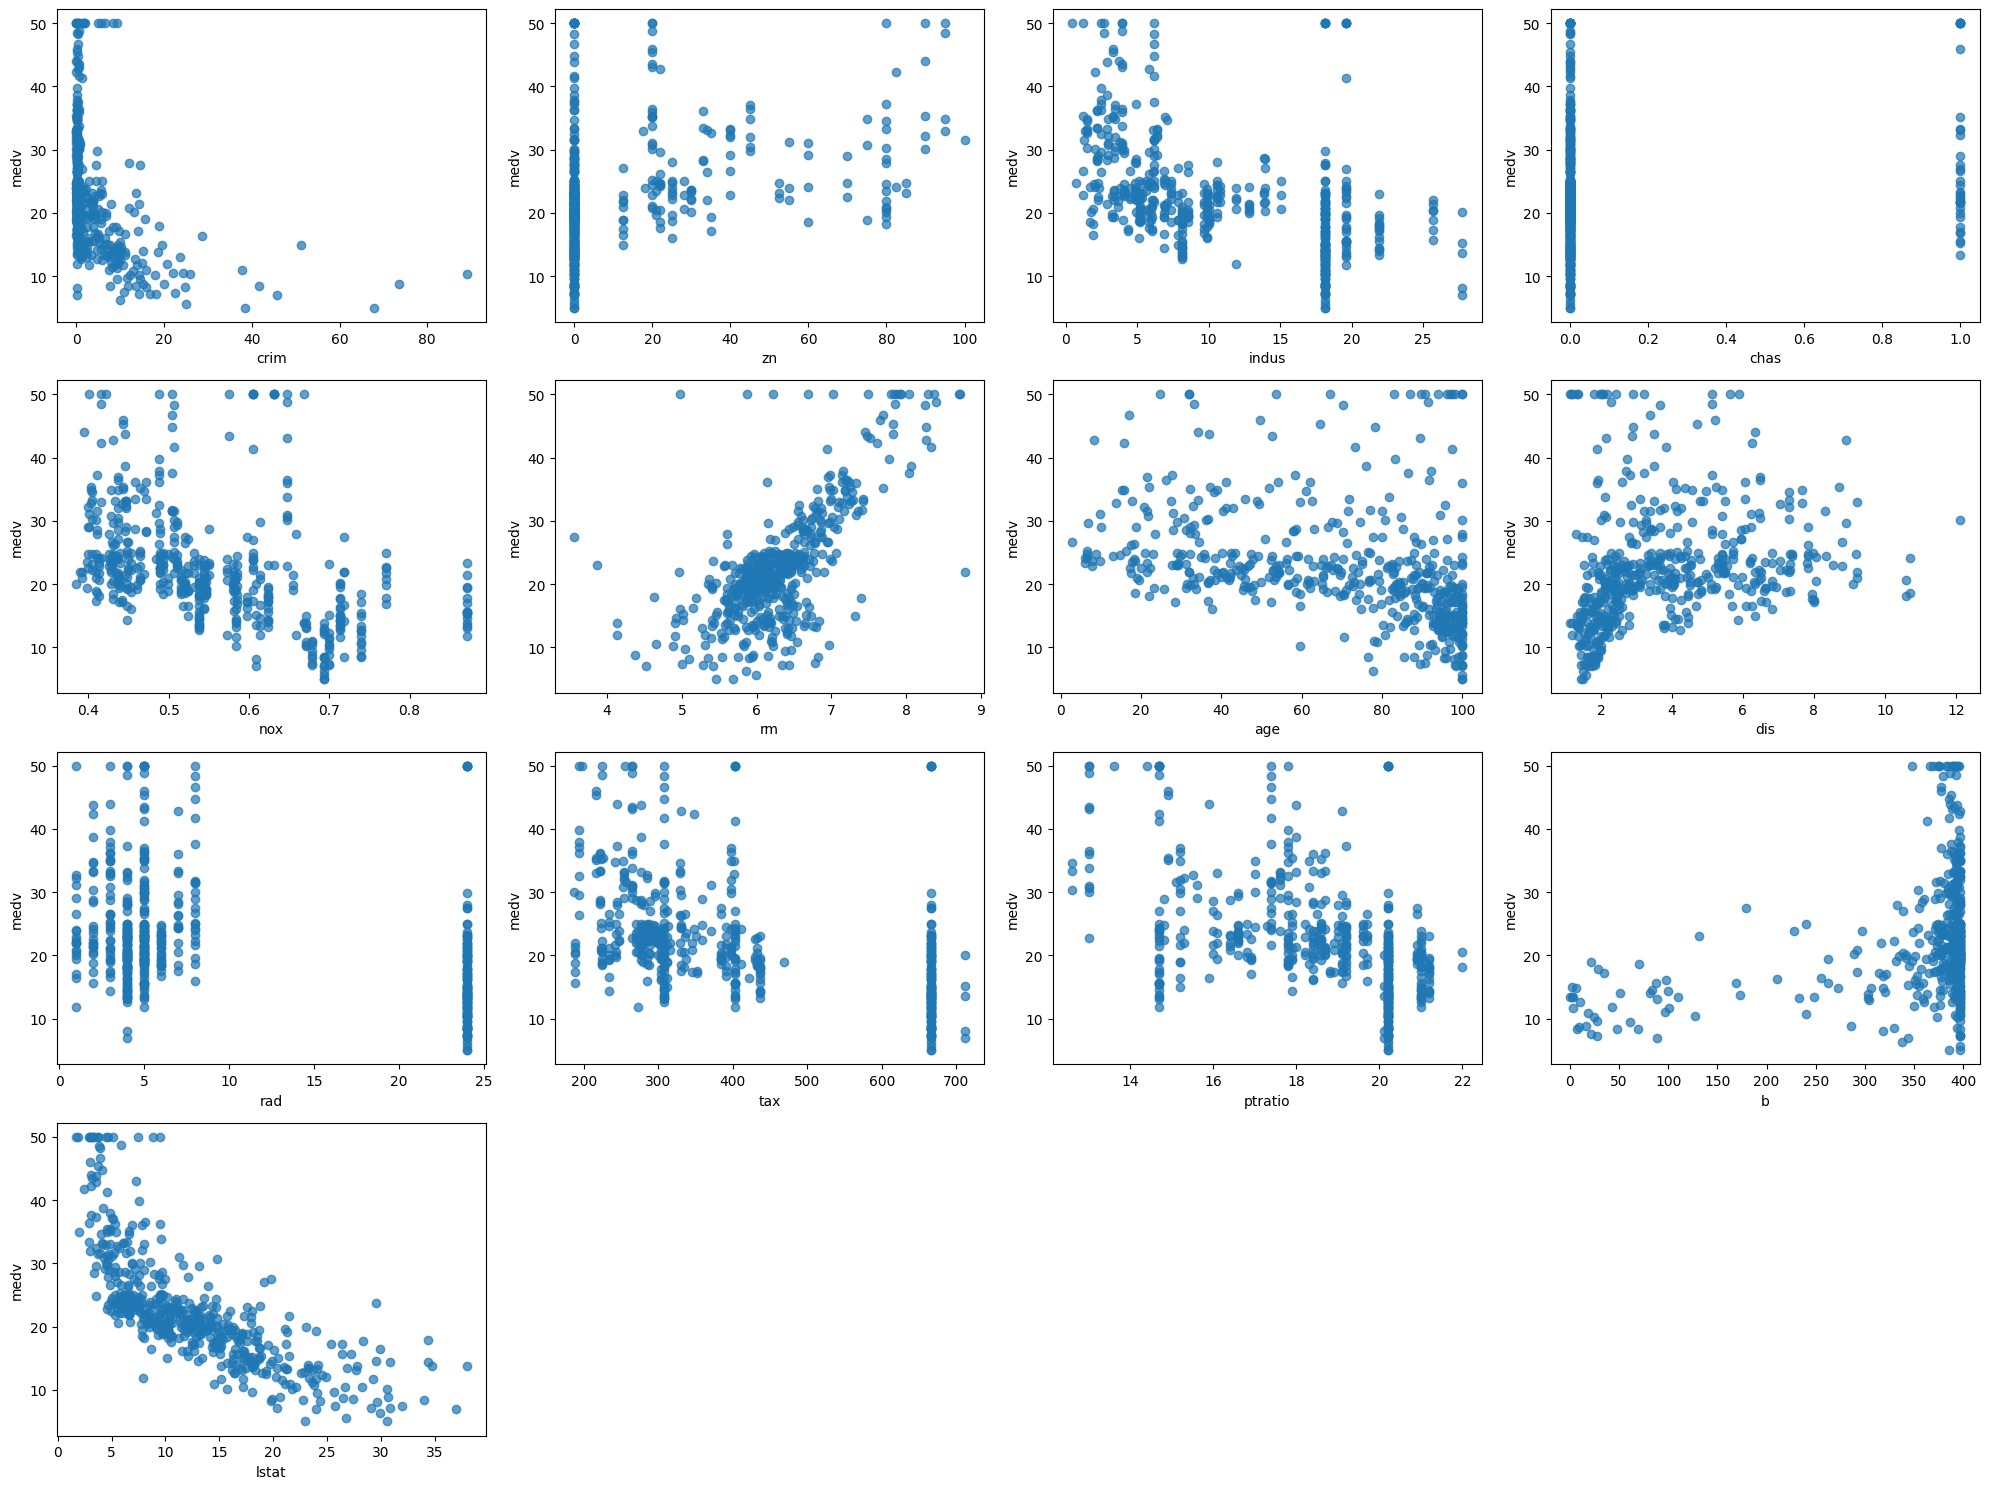

In [7]:
target = 'medv'

# Set figure size
plt.figure(figsize=(20, 15))

# Loop over each feature and plot against target
for i, col in enumerate(df.columns.drop(target), 1):
    plt.subplot(4, 4, i)  # Adjust grid depending on number of features
    plt.scatter(df[col], df[target], alpha=0.7)
    plt.xlabel(col)
    plt.ylabel(target)
plt.tight_layout()
plt.show()

In [8]:
# Separate features and target
X = df.drop(target, axis=1)
y = df[target]

# First split: 60% train, 40% temp (validation+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Split temp into 50% validation, 50% test (20% each of original dataset)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Check shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (303, 13) (303,)
Validation shape: (101, 13) (101,)
Test shape: (102, 13) (102,)


In [9]:
# Mean and standard deviation of features
mean_std = pd.DataFrame({
    "Mean": X_train.mean(),
    "Std": X_train.std()
})
mean_std

,Mean,Std
crim,3.345161,7.925900
zn,12.316832,23.717019
indus,11.020396,6.984761
chas,0.066007,0.248704
nox,0.552900,0.115472
rm,6.344677,0.733410
age,67.994389,27.802673
dis,3.851676,2.173709
rad,9.330033,8.633256
tax,403.603960,166.179354


In [10]:
# Correlation matrix with target
correlation = df.corr()[target].sort_values(ascending=False)
correlation

medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

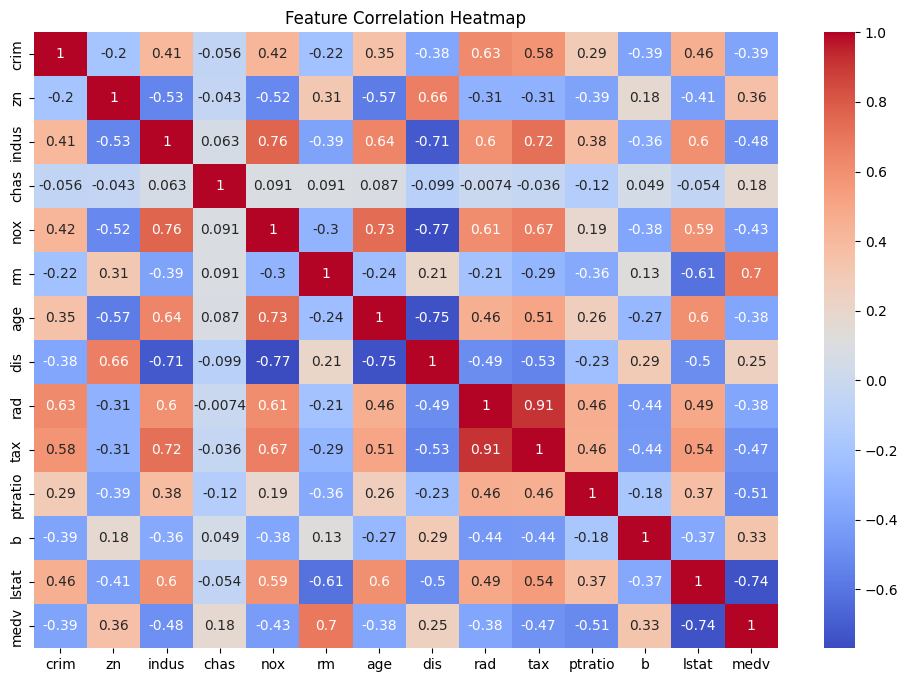

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Gradient descent and normal equation

In [12]:
# Re-standardize everything fresh
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

In [13]:
 # Add bias column (important even after scaling)
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]

# Initialize theta
theta = np.zeros((X_train_b.shape[1], 1))
learning_rate = 0.001   # slightly higher
n_iterations = 10000   # more iterations
m = len(y_train_scaled)

losses = []

for iteration in range(n_iterations):
    predictions = X_train_b.dot(theta)
    error = predictions - y_train_scaled
    gradients = (2/m) * X_train_b.T.dot(error)
    theta = theta - learning_rate * gradients
    
    mse = np.mean(error**2)
    losses.append(mse)

# Predictions on validation set
y_val_pred_scaled = X_val_b.dot(theta)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled)

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Gradient Descent Results (fixed):")
print("MSE:", mse)
print("R²:", r2)


Gradient Descent Results (fixed):
MSE: 18.87071208923162
R²: 0.7130626405101432


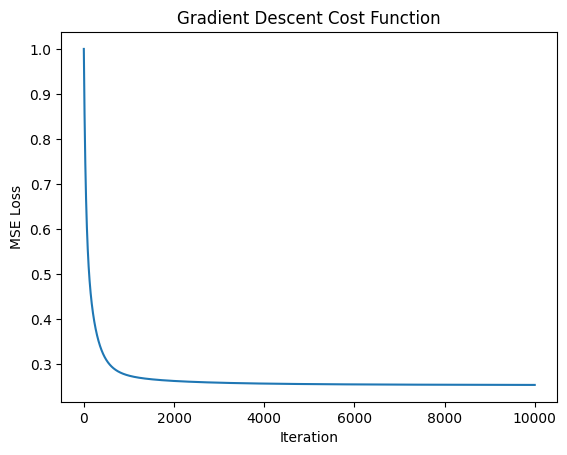

In [14]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Cost Function")
plt.show()

In [15]:
# Add bias column (unscaled data)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train.values]
X_val_b   = np.c_[np.ones((X_val.shape[0], 1)), X_val.values]

y_train_array = y_train.values.reshape(-1, 1)

# Normal Equation: theta = (X^T * X)^(-1) * X^T * y
theta_normal = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train_array)

# Predictions
y_val_pred_ne = X_val_b.dot(theta_normal)

# Evaluation
mse_ne = mean_squared_error(y_val, y_val_pred_ne)
r2_ne = r2_score(y_val, y_val_pred_ne)

print("Normal Equation Results:")
print("MSE:", mse_ne)
print("R²:", r2_ne)


Normal Equation Results:
MSE: 18.603252311861652
R²: 0.7171294823932367


In [16]:
print("Gradient Descent (scaled features):")
print("MSE:", mse)
print("R²:", r2)

print("\nNormal Equation (unscaled features):")
print("MSE:", mse_ne)
print("R²:", r2_ne)

Gradient Descent (scaled features):
MSE: 18.87071208923162
R²: 0.7130626405101432

Normal Equation (unscaled features):
MSE: 18.603252311861652
R²: 0.7171294823932367


In [17]:
import time

# ---- Timing Gradient Descent ----
start_time = time.time()
theta = np.zeros((X_train_b.shape[1], 1))

# Gradient Descent loop (assumes X_train_b, y_train_scaled, learning_rate, n_iterations defined)
for iteration in range(n_iterations):
    predictions = X_train_b.dot(theta)
    error = predictions - y_train_scaled
    gradients = (2 / X_train_b.shape[0]) * X_train_b.T.dot(error)
    theta -= learning_rate * gradients
    losses.append((error**2).mean())

gd_time = time.time() - start_time

# ---- Timing Normal Equation ----
start_time = time.time()

# Normal Equation (assumes X_train_b_ne, y_train_array defined)
theta_normal = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train_array)

ne_time = time.time() - start_time

# ---- Comparison ----
print("Training Time:")
print(f"Gradient Descent: {gd_time:.4f} seconds")
print(f"Normal Equation: {ne_time:.6f} seconds")

print("\nFinal Weights (first 5):")
print("Gradient Descent:", theta.ravel()[:5])
print("Normal Equation:", theta_normal.ravel()[:5])

Training Time:
Gradient Descent: 0.1155 seconds
Normal Equation: 0.000000 seconds

Final Weights (first 5):
Gradient Descent: [nan nan nan nan nan]
Normal Equation: [ 3.43302608e+01 -1.13498178e-01  3.79976868e-02  2.99876109e-02
  3.51131977e+00]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18280\877413158.py:13: RuntimeWarning: overflow encountered in square
  losses.append((error**2).mean())


Polynomial Regression

In [18]:
# Define degrees to test
degrees = [1, 2, 3, 5]
train_errors = []
val_errors = []
results = []

# Train models with different polynomial degrees
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly   = poly.transform(X_val)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_val_pred   = model.predict(X_val_poly)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse   = mean_squared_error(y_val, y_val_pred)
    train_r2  = r2_score(y_train, y_train_pred)
    val_r2    = r2_score(y_val, y_val_pred)
    
    train_errors.append(train_mse)
    val_errors.append(val_mse)

    results.append({
        "Degree": d,
        "Train MSE": train_mse,
        "Validation MSE": val_mse,
        "Train R²": train_r2,
        "Validation R²": val_r2
    })

# Display results in a table
df_results = pd.DataFrame(results)
df_results

,Degree,Train MSE,Validation MSE,Train R²,Validation R²
0,1,2.255652e+01,18.603252,0.747200,0.717129
1,2,4.007008e+00,23.356155,0.955092,0.644860
2,3,2.350081e-19,7827.961326,1.000000,-118.027546
3,5,1.440658e-21,4113.147706,1.000000,-61.542194


In [19]:
df.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [20]:
my_input = np.array([[0.00632	,18.0	,2.31	,0	,0.538	,6.575	,65.2	,4.0900,	1,	296,	15.3,	396.90,	4.98]])

In [21]:
# Scale input using the same scaler as training
my_input_scaled = scaler_X.transform(my_input)

# Add bias column
my_input_b = np.c_[np.ones((my_input_scaled.shape[0], 1)), my_input_scaled]

# Predict using Gradient Descent theta
my_pred_scaled = my_input_b.dot(theta)

# Convert back to original MEDV scale
my_pred = scaler_y.inverse_transform(my_pred_scaled)

print("Predicted MEDV (Gradient Descent):", my_pred[0][0])


Predicted MEDV (Gradient Descent): nan


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
# ---- If using Normal Equation (unscaled features) ----
my_input_b_ne = np.c_[np.ones((my_input.shape[0], 1)), my_input]  # add bias
my_pred_ne = my_input_b_ne.dot(theta_normal)

print("Predicted MEDV (Normal Equation):", my_pred_ne[0][0])

Predicted MEDV (Normal Equation): 30.224519916004244


In [23]:
# Choose the degree to test
test_degree = 2 

# Create polynomial features
poly = PolynomialFeatures(degree=test_degree)
X_train_poly = poly.fit_transform(X_train)  # required for fitting model
X_val_poly   = poly.transform(X_val)
my_input_poly = poly.transform(my_input)

# Train model for that degree
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict for your input
my_pred = model.predict(my_input_poly)

print(f"Predicted MEDV for degree {test_degree}:", my_pred[0])

Predicted MEDV for degree 2: 26.96906305917922


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


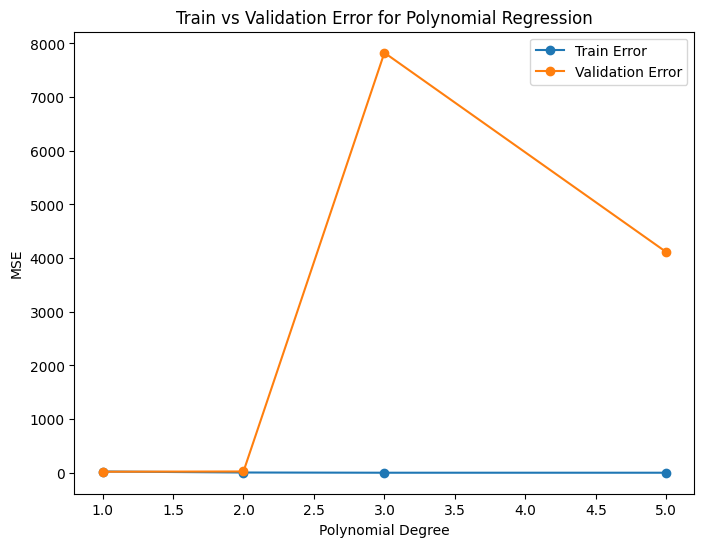

In [24]:
# Plot Train vs Validation error
plt.figure(figsize=(8,6))
plt.plot(degrees, train_errors, marker='o', label="Train Error")
plt.plot(degrees, val_errors, marker='o', label="Validation Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Train vs Validation Error for Polynomial Regression")
plt.legend()
plt.show()

In [25]:
# Define training set sizes
train_sizes = [50, 100, 200, 300, 400]

train_errors_lc = []
val_errors_lc = []
# Loop over training sizes
for size in train_sizes:
    # Take subset of training data
    X_subset = X_train[:size]
    y_subset = y_train[:size]
    
    model = LinearRegression()
    model.fit(X_subset, y_subset)
    
    # Predictions
    y_train_pred = model.predict(X_subset)
    y_val_pred   = model.predict(X_val)
    
    # Errors
    train_mse = mean_squared_error(y_subset, y_train_pred)
    val_mse   = mean_squared_error(y_val, y_val_pred)
    
    train_errors_lc.append(train_mse)
    val_errors_lc.append(val_mse)

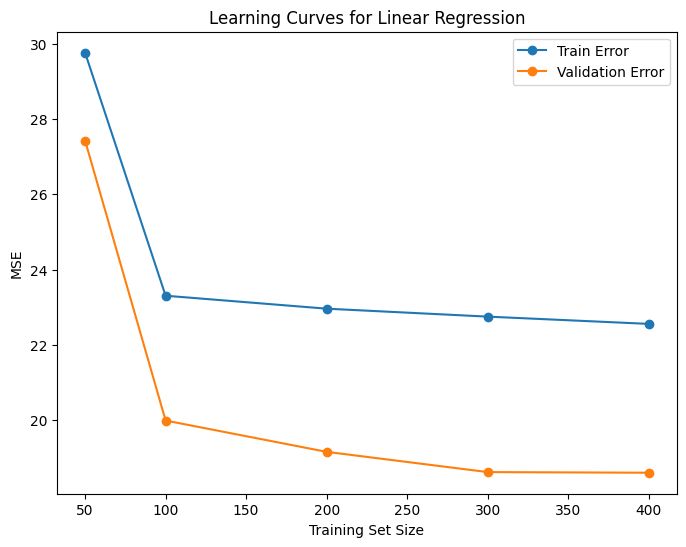

In [26]:
# Plot learning curves
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_errors_lc, marker='o', label="Train Error")
plt.plot(train_sizes, val_errors_lc, marker='o', label="Validation Error")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title("Learning Curves for Linear Regression")
plt.legend()
plt.show()

In [27]:
lc_results = pd.DataFrame({
    "Train Size": train_sizes,
    "Train MSE": train_errors_lc,
    "Validation MSE": val_errors_lc
})
lc_results

,Train Size,Train MSE,Validation MSE
0,50,29.758868,27.425082
1,100,23.304573,19.989240
2,200,22.960425,19.157872
3,300,22.749432,18.619938
4,400,22.556523,18.603252
